# Практика 21. Метод Монте-Карло

**Варіант:** 7  
**Місто:** Івано-Франківськ  
**Тип задачі:** математичне сподівання  

## Задача

Оцінити методом Монте-Карло математичне сподівання мінімуму із трьох кидків шестигранного кубика.

Точне аналітичне значення:

E[min(X₁, X₂, X₃)] = 49/24 ≈ 2.0417

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

N = 1000

rolls = np.random.randint(1, 7, size=(N, 3))
minimums = rolls.min(axis=1)

mc_estimate = minimums.mean()

print("N =", N)
print("Monte Carlo estimate =", mc_estimate)

N = 1000
Monte Carlo estimate = 1.967


## Завдання 2. Порівняння з точним значенням

In [2]:
exact_value = 49 / 24

absolute_error = abs(mc_estimate - exact_value)
relative_error_percent = absolute_error / exact_value * 100

print("Точне значення =", exact_value)
print("Оцінка Монте-Карло =", mc_estimate)
print("Абсолютна похибка =", absolute_error)
print("Відносна похибка, % =", relative_error_percent)

Точне значення = 2.0416666666666665
Оцінка Монте-Карло = 1.967
Абсолютна похибка = 0.07466666666666644
Відносна похибка, % = 3.6571428571428464


Отримана оцінка методом Монте-Карло наближена до точного значення 49/24 ≈ 2.0417. Абсолютна похибка є відносно невеликою порівняно з самим значенням математичного сподівання. Відмінність виникає через випадковий характер моделювання та обмежену кількість випробувань N = 1000. Зі збільшенням кількості випробувань оцінка повинна наближатися до точного значення.

## Завдання 3. Збіжність за кількістю випробувань

Перевіримо поведінку оцінки при N = 100, 1000, 10000 та 100000.
Перед кожною симуляцією фіксуємо `np.random.seed(7)` для відтворюваності.



In [3]:
Ns = [100, 1000, 10000, 100000]

results = []

for N in Ns:
    np.random.seed(7)

    rolls = np.random.randint(1, 7, size=(N, 3))
    minimums = rolls.min(axis=1)

    estimate = minimums.mean()
    error = abs(estimate - exact_value)

    results.append((N, estimate, error))

print("N\t\tОцінка\t\tАбсолютна похибка")

for N, estimate, error in results:
    print(f"{N}\t\t{estimate:.6f}\t{error:.6f}")

N		Оцінка		Абсолютна похибка
100		2.100000	0.058333
1000		1.967000	0.074667
10000		2.031000	0.010667
100000		2.039700	0.001967


In [4]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["N", "Оцінка", "Абсолютна похибка"]
)

results_df

,N,Оцінка,Абсолютна похибка
0,100,2.1000,0.058333
1,1000,1.9670,0.074667
2,10000,2.0310,0.010667
3,100000,2.0397,0.001967


При збільшенні кількості випробувань оцінка математичного сподівання в середньому наближається до точного значення 49/24 ≈ 2.0417. Похибка не зобов'язана спадати строго монотонно, оскільки результати симуляції залежать від випадкових чисел.

При переході від N = 100 до N = 10000 кількість випробувань збільшується у 100 разів. Відповідно до теорії Монте-Карло та стандартної похибки, характерний масштаб похибки повинен зменшитися приблизно у √100 = 10 разів, а не у 100 разів. Це демонструє залежність похибки від 1/√N.

## Завдання 4. Графік похибки залежно від N

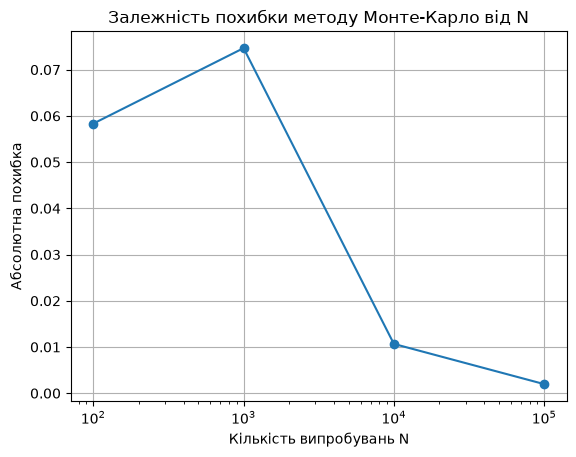

In [5]:
N_values = [row[0] for row in results]
errors = [row[2] for row in results]

fig, ax = plt.subplots()

ax.plot(N_values, errors, marker="o")
ax.set_xscale("log")

ax.set_xlabel("Кількість випробувань N")
ax.set_ylabel("Абсолютна похибка")
ax.set_title("Залежність похибки методу Монте-Карло від N")

ax.grid(True)
plt.show()

На графіку видно загальну тенденцію до зменшення абсолютної похибки зі збільшенням кількості випробувань. Оскільки результати залежать від випадкової генерації, спадання не обов'язково є строго монотонним.

Форма кривої відповідає очікуваній поведінці порядку 1/√N: зі збільшенням N похибка зменшується, але значно повільніше, ніж сама кількість випробувань.

## Завдання 5. Зв'язок із законом великих чисел і ЦГТ

Оцінка методом Монте-Карло є вибірковим середнім результатів великої кількості незалежних випробувань.

### 1. Який результат гарантує збіжність?

Збіжність оцінки до точного математичного сподівання гарантує закон великих чисел. Він стверджує, що при збільшенні кількості незалежних однаково розподілених випробувань вибіркове середнє наближається до математичного сподівання випадкової величини.

У цій роботі кожним випробуванням є три кидки кубика, а випадковою величиною є мінімальне значення серед цих трьох кидків. Тому середнє значення масиву `minimums` наближається до точного математичного сподівання 49/24.

### 2. Чому похибка зменшується як 1/√N?

Центральна гранична теорема пояснює масштаб випадкових коливань вибіркового середнього. Стандартна похибка середнього має вигляд:

σ/√N

Отже, якщо кількість випробувань збільшити у 4 рази, характерна похибка зменшиться приблизно у 2 рази. Якщо збільшити N у 100 разів, похибка зменшиться приблизно у 10 разів.

Таким чином, залежність 1/√N є не окремою властивістю саме методу Монте-Карло, а наслідком загальних властивостей вибіркового середнього та центральної граничної теореми.

## Контрольні питання

### 1. Чому оцінка методом Монте-Карло — це, по суті, вибіркове середнє?

Метод Монте-Карло використовує велику кількість незалежних випадкових випробувань і усереднює отримані результати. У нашій задачі для кожного випробування визначається мінімум із трьох кидків кубика, після чого обчислюється середнє всіх отриманих мінімумів.

Закон великих чисел гарантує, що при збільшенні кількості випробувань це вибіркове середнє наближається до математичного сподівання.

### 2. Чому вчетверо більша кількість випробувань дає лише вдвічі меншу похибку?

Стандартна похибка вибіркового середнього визначається формулою:

σ/√N

Якщо N збільшити у 4 рази, знаменник √N збільшиться у √4 = 2 рази. Тому характерна похибка зменшиться приблизно вдвічі, а не вчетверо.

### 3. Для варіанта типу «площа»

Це питання не стосується варіанта 7, оскільки мій варіант є задачею на математичне сподівання. Для задачі на площу частка точок усередині фігури множиться на площу прямокутника-охоплення, оскільки частка є лише відношенням площі фігури до площі прямокутника.

### 4. Чому використовується `.min(axis=1)`?

У моїй задачі кожен рядок матриці містить три кидки одного випробування. Вираз `min(axis=1)` знаходить мінімум окремо в кожному рядку та повертає масив із N результатів.

Якби використати `.min()` без `axis`, було б знайдено одне мінімальне значення серед усієї матриці, тобто втрачено результати окремих випробувань.

## Висновок

У практичній роботі було застосовано метод Монте-Карло для оцінювання математичного сподівання мінімуму із трьох кидків шестигранного кубика для варіанта 7 (Івано-Франківськ). Теоретичне значення задачі становить 49/24 ≈ 2.0417.

За допомогою випадкової генерації було отримано оцінку математичного сподівання та визначено її абсолютну похибку. Дослідження для різних значень N показало загальну тенденцію до зменшення похибки зі збільшенням кількості випробувань.

Експеримент підтвердив теоретичну залежність характерної похибки від 1/√N. При збільшенні кількості випробувань у 100 разів очікується зменшення характерного масштабу похибки приблизно у 10 разів. Збіжність оцінки до точного математичного сподівання пояснюється законом великих чисел, а масштаб випадкової похибки вибіркового середнього — центральною граничною теоремою.

Таким чином, метод Монте-Карло дозволяє отримувати все точніші оцінки цільової величини шляхом збільшення кількості випадкових випробувань.